# 04 — Absolute vs Object-Relative Geometry

## Goal

This notebook investigates whether explicit spatial coordinates provide useful
information beyond frozen DINOv2 features, frozen CLIP text features, and
parent-object conditioning.

This directly addresses the project feedback:

> Compare object-relative (U,V) coordinates with absolute image coordinates
> to determine whether the relative coordinate system itself provides a
> meaningful benefit.

We compare three controlled models:

### Experiment 1 — Object Mask

DINOv2 + CLIP + parent-object mask

Coordinate channels are present but filled with zeros.

### Experiment 2 — Absolute XY

DINOv2 + CLIP + parent-object mask + absolute image X/Y coordinates

X describes horizontal position in the complete image.

Y describes vertical position in the complete image.

### Experiment 3 — Relative UV

DINOv2 + CLIP + parent-object mask + object-relative U/V coordinates

U describes horizontal position inside the parent object's bounding box.

V describes vertical position inside the parent object's bounding box.

## Main Research Question

Does explicit spatial information improve part segmentation beyond DINOv2,
and if so, does defining position relative to the parent object provide more
useful information than absolute image coordinates?

## Important Control

All three models use:

- the same DINOv2 encoder;
- the same CLIP encoder;
- the same visual/text projections;
- the same decoder;
- the same number of channels;
- the same train/validation/test splits;
- the same loss;
- the same optimizer;
- the same seed;
- the same training settings.

Only the information contained in the two coordinate channels changes.

In [1]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [3]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [4]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_DIM = 32

MASK_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "geometry"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output:", OUTPUT_ROOT)

Device: cuda
AMP: True
Output: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/geometry


In [5]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [6]:
raw_train_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_val_dataset = PascalPart116Dataset(
    split="validation_seen"
)

raw_test_seen_dataset = PascalPart116Dataset(
    split="test_seen"
)

raw_test_unseen_dataset = PascalPart116Dataset(
    split="test_unseen"
)

print("Train:", len(raw_train_dataset))
print("Validation:", len(raw_val_dataset))
print("Test seen:", len(raw_test_seen_dataset))
print("Test unseen:", len(raw_test_unseen_dataset))

Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


In [7]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [8]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(height * scale),
    )

    new_w = max(
        1,
        round(width * scale),
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

In [9]:
def preprocess_image(
    image,
    target_size=224,
):

    image = image.float() / 255.0

    _, h, w = image.shape

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

In [10]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return padded > 0.5

## Absolute Image Coordinates

Absolute X/Y coordinates describe where a pixel lies in the complete
224 × 224 image.

For horizontal position:

X = x / (W - 1)

Therefore:

- X = 0 at the left edge
- X = 0.5 near the image centre
- X = 1 at the right edge

For vertical position:

Y = y / (H - 1)

Therefore:

- Y = 0 at the top
- Y = 0.5 near the image centre
- Y = 1 at the bottom

These coordinates change when an object moves inside the image.

In [12]:
def create_absolute_xy(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    y = torch.linspace(
        0.0,
        1.0,
        h,
        dtype=torch.float32,
    )

    x = torch.linspace(
        0.0,
        1.0,
        w,
        dtype=torch.float32,
    )

    yy, xx = torch.meshgrid(
        y,
        x,
        indexing="ij",
    )

    mask_float = mask.float()

    absolute_x = (
        xx * mask_float
    )

    absolute_y = (
        yy * mask_float
    )

    return (
        absolute_x.unsqueeze(0),
        absolute_y.unsqueeze(0),
    )

## Object-Relative Coordinates

Relative U/V coordinates describe where a pixel lies inside the bounding
box of the selected parent object.

For horizontal object-relative position:

U = (x - xmin) / (xmax - xmin)

Therefore:

- U = 0 at the left side of the object
- U = 0.5 near the horizontal object centre
- U = 1 at the right side of the object

For vertical object-relative position:

V = (y - ymin) / (ymax - ymin)

Therefore:

- V = 0 at the top of the object
- V = 0.5 near the vertical object centre
- V = 1 at the bottom of the object

Unlike absolute X/Y, relative U/V are approximately invariant to object
translation and scale.

They are still sensitive to object orientation.

In [13]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    u_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(
        mask
    )

    if len(xs) == 0:

        return (
            u_map.unsqueeze(0),
            v_map.unsqueeze(0),
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    x_denom = max(
        int(x_max - x_min),
        1,
    )

    y_denom = max(
        int(y_max - y_min),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u_map[
        ys,
        xs,
    ] = u_values

    v_map[
        ys,
        xs,
    ] = v_values

    return (
        u_map.unsqueeze(0),
        v_map.unsqueeze(0),
    )

In [14]:
raw_sample = raw_train_dataset[0]

display_image, model_image, resize_info = (
    preprocess_image(
        raw_sample["image"],
        IMAGE_SIZE,
    )
)

object_mask = preprocess_mask(
    raw_sample["object_mask"],
    resize_info,
    preserve_positive=True,
)

part_mask = preprocess_mask(
    raw_sample["part_mask"],
    resize_info,
    preserve_positive=True,
)

absolute_x, absolute_y = (
    create_absolute_xy(
        object_mask
    )
)

relative_u, relative_v = (
    create_relative_uv(
        object_mask
    )
)

print(
    "Object:",
    raw_sample["object_name"]
)

print(
    "Part:",
    raw_sample["part_name"]
)

print()

print(
    "Absolute X:",
    absolute_x.shape,
    absolute_x.min().item(),
    absolute_x.max().item(),
)

print(
    "Absolute Y:",
    absolute_y.shape,
    absolute_y.min().item(),
    absolute_y.max().item(),
)

print(
    "Relative U:",
    relative_u.shape,
    relative_u.min().item(),
    relative_u.max().item(),
)

print(
    "Relative V:",
    relative_v.shape,
    relative_v.min().item(),
    relative_v.max().item(),
)

Object: tvmonitor
Part: screen

Absolute X: torch.Size([1, 224, 224]) 0.0 0.8923766613006592
Absolute Y: torch.Size([1, 224, 224]) 0.0 0.6860986351966858
Relative U: torch.Size([1, 224, 224]) 0.0 1.0
Relative V: torch.Size([1, 224, 224]) 0.0 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


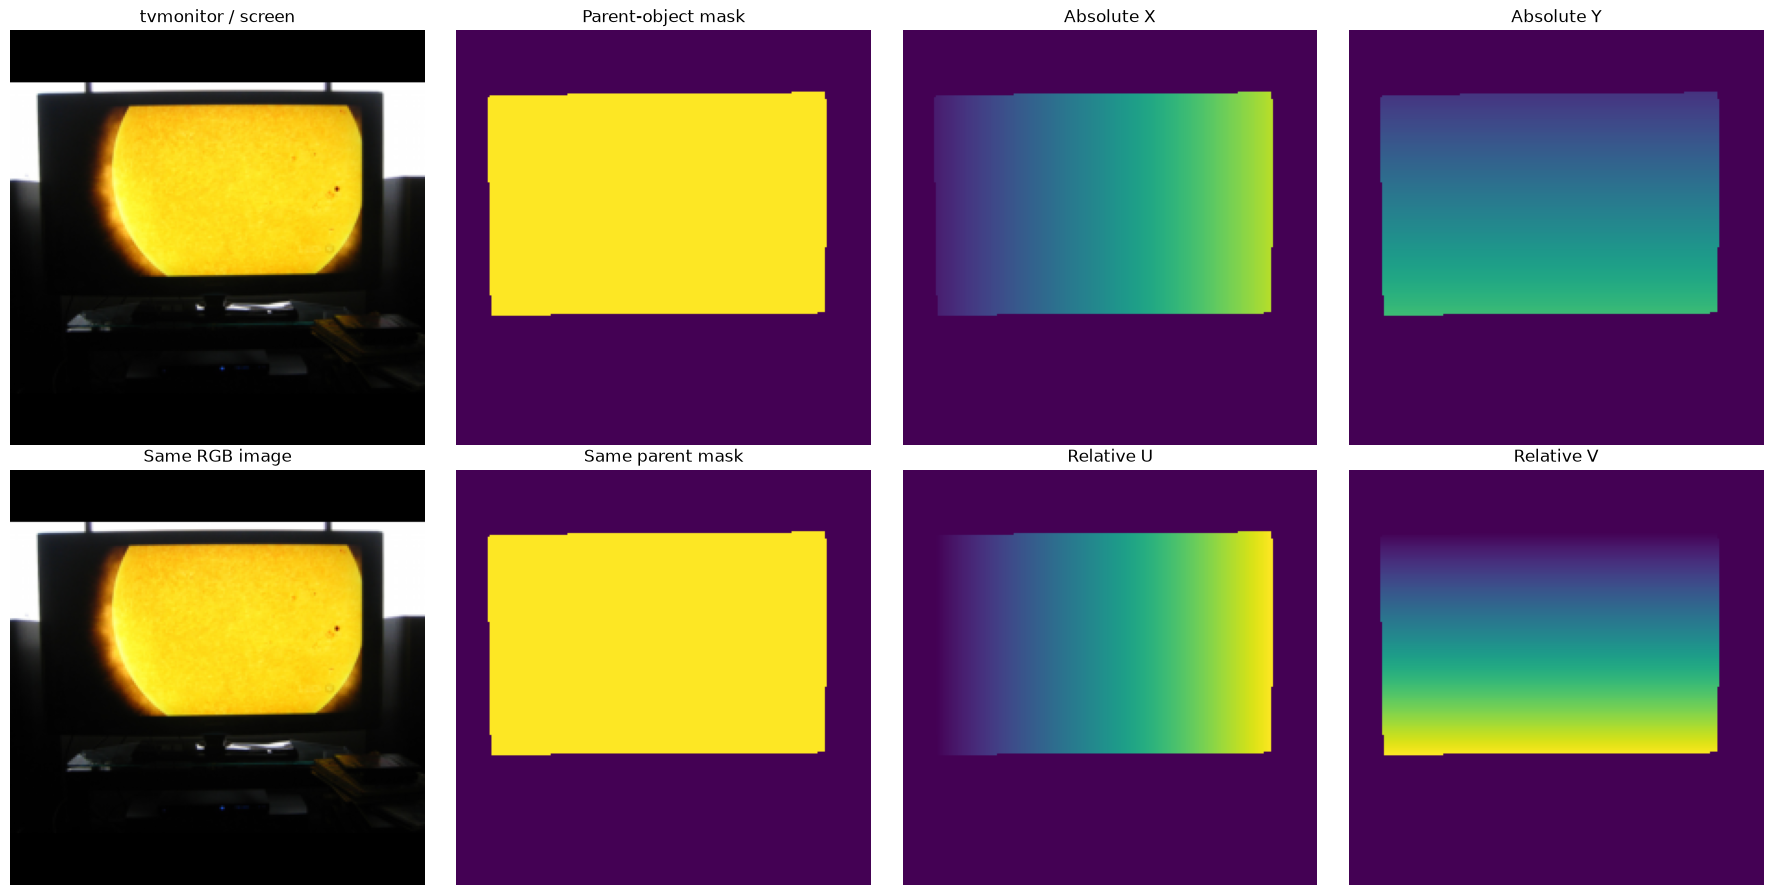

In [15]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
)

axes[0, 0].imshow(
    display_image
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    f"{raw_sample['object_name']} / "
    f"{raw_sample['part_name']}"
)

axes[0, 1].imshow(
    object_mask.squeeze()
)

axes[0, 1].set_title(
    "Parent-object mask"
)

axes[0, 2].imshow(
    absolute_x.squeeze(),
    vmin=0,
    vmax=1,
)

axes[0, 2].set_title(
    "Absolute X"
)

axes[0, 3].imshow(
    absolute_y.squeeze(),
    vmin=0,
    vmax=1,
)

axes[0, 3].set_title(
    "Absolute Y"
)

axes[1, 0].imshow(
    display_image
    .permute(1, 2, 0)
)

axes[1, 0].set_title(
    "Same RGB image"
)

axes[1, 1].imshow(
    object_mask.squeeze()
)

axes[1, 1].set_title(
    "Same parent mask"
)

axes[1, 2].imshow(
    relative_u.squeeze(),
    vmin=0,
    vmax=1,
)

axes[1, 2].set_title(
    "Relative U"
)

axes[1, 3].imshow(
    relative_v.squeeze(),
    vmin=0,
    vmax=1,
)

axes[1, 3].set_title(
    "Relative V"
)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
mask_2d = object_mask.squeeze().bool()

ys, xs = torch.where(mask_2d)

left_idx = xs.argmin()
right_idx = xs.argmax()

top_idx = ys.argmin()
bottom_idx = ys.argmax()

positions = {
    "left": (
        ys[left_idx].item(),
        xs[left_idx].item(),
    ),

    "right": (
        ys[right_idx].item(),
        xs[right_idx].item(),
    ),

    "top": (
        ys[top_idx].item(),
        xs[top_idx].item(),
    ),

    "bottom": (
        ys[bottom_idx].item(),
        xs[bottom_idx].item(),
    ),
}

for name, (y, x) in positions.items():

    print(
        f"{name:7s}",
        f"pixel=({x},{y})",
        f"X={absolute_x[0,y,x]:.3f}",
        f"Y={absolute_y[0,y,x]:.3f}",
        f"U={relative_u[0,y,x]:.3f}",
        f"V={relative_v[0,y,x]:.3f}",
    )

left    pixel=(17,36) X=0.076 Y=0.161 U=0.000 V=0.025
right   pixel=(199,37) X=0.892 Y=0.166 U=1.000 V=0.033
top     pixel=(181,33) X=0.812 Y=0.148 U=0.901 V=0.000
bottom  pixel=(19,153) X=0.085 Y=0.686 U=0.011 V=1.000


In [17]:
class GeometryDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = (
            image_size
        )

    def __len__(self):

        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index,
    ):

        sample = (
            self.base_dataset[index]
        )

        (
            display_image,
            image,
            resize_info,
        ) = preprocess_image(
            sample["image"],
            self.image_size,
        )

        object_mask = preprocess_mask(
            sample["object_mask"],
            resize_info,
            preserve_positive=True,
        )

        part_mask = preprocess_mask(
            sample["part_mask"],
            resize_info,
            preserve_positive=True,
        )

        overlap = (
            object_mask
            & part_mask
        )

        if (
            part_mask.any()
            and not overlap.any()
        ):

            object_mask = (
                object_mask
                | part_mask
            )

        part_mask = (
            part_mask
            & object_mask
        )

        (
            absolute_x,
            absolute_y,
        ) = create_absolute_xy(
            object_mask
        )

        (
            relative_u,
            relative_v,
        ) = create_relative_uv(
            object_mask
        )

        return {
            "sample_id": (
                sample["sample_id"]
            ),

            "image_id": (
                sample["image_id"]
            ),

            "image": (
                image
            ),

            "display_image": (
                display_image
            ),

            "object_mask": (
                object_mask.float()
            ),

            "part_mask": (
                part_mask.float()
            ),

            "absolute_x": (
                absolute_x
            ),

            "absolute_y": (
                absolute_y
            ),

            "relative_u": (
                relative_u
            ),

            "relative_v": (
                relative_v
            ),

            "query": (
                sample["query"]
            ),

            "object_name": (
                sample["object_name"]
            ),

            "part_name": (
                sample["part_name"]
            ),

            "evaluation_split": (
                sample["evaluation_split"]
            ),
        }

In [18]:
train_dataset = GeometryDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
)

val_dataset = GeometryDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
)

test_seen_dataset = GeometryDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
)

test_unseen_dataset = GeometryDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_seen_dataset),
    len(test_unseen_dataset),
)

32698 3708 3371 1586


In [19]:
sample = train_dataset[0]

for key, value in sample.items():

    if torch.is_tensor(value):

        print(
            f"{key:20s}",
            tuple(value.shape),
            value.dtype,
        )

    else:

        print(
            f"{key:20s}",
            value,
        )

sample_id            train:2008_000002:part_115
image_id             2008_000002
image                (3, 224, 224) torch.float32
display_image        (3, 224, 224) torch.float32
object_mask          (1, 224, 224) torch.float32
part_mask            (1, 224, 224) torch.float32
absolute_x           (1, 224, 224) torch.float32
absolute_y           (1, 224, 224) torch.float32
relative_u           (1, 224, 224) torch.float32
relative_v           (1, 224, 224) torch.float32
query                screen
object_name          tvmonitor
part_name            screen
evaluation_split     seen


In [20]:
def validate_geometry_sample(
    sample,
):

    expected_image_shape = (
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    expected_map_shape = (
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    assert (
        sample["image"].shape
        == expected_image_shape
    )

    for key in [
        "object_mask",
        "part_mask",
        "absolute_x",
        "absolute_y",
        "relative_u",
        "relative_v",
    ]:

        assert (
            sample[key].shape
            == expected_map_shape
        ), key

    obj = (
        sample["object_mask"]
        > 0.5
    )

    part = (
        sample["part_mask"]
        > 0.5
    )

    assert torch.all(
        ~part | obj
    )

    for key in [
        "absolute_x",
        "absolute_y",
        "relative_u",
        "relative_v",
    ]:

        assert (
            sample[key].min()
            >= 0
        )

        assert (
            sample[key].max()
            <= 1
        )

    return True


validate_geometry_sample(
    train_dataset[0]
)

True

In [21]:
rng = random.Random(SEED)

indices = rng.sample(
    range(len(train_dataset)),
    min(
        200,
        len(train_dataset),
    ),
)

for idx in indices:

    validate_geometry_sample(
        train_dataset[idx]
    )

print(
    f"Validated {len(indices)} "
    "geometry samples successfully."
)

Validated 200 geometry samples successfully.


In [22]:
PIN_MEMORY = (
    DEVICE.type == "cuda"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

In [23]:
batch = next(
    iter(train_loader)
)

for key in [
    "image",
    "object_mask",
    "part_mask",
    "absolute_x",
    "absolute_y",
    "relative_u",
    "relative_v",
]:

    print(
        f"{key:15s}",
        batch[key].shape,
    )

image           torch.Size([16, 3, 224, 224])
object_mask     torch.Size([16, 1, 224, 224])
part_mask       torch.Size([16, 1, 224, 224])
absolute_x      torch.Size([16, 1, 224, 224])
absolute_y      torch.Size([16, 1, 224, 224])
relative_u      torch.Size([16, 1, 224, 224])
relative_v      torch.Size([16, 1, 224, 224])


In [24]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(
    DEVICE
)

dino.eval()

for parameter in dino.parameters():

    parameter.requires_grad = False

print(
    "DINOv2 loaded and frozen."
)

Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded and frozen.


In [25]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = (
    clip_model
    .to(DEVICE)
)

clip_model.eval()

for parameter in (
    clip_model.parameters()
):

    parameter.requires_grad = False

print(
    "CLIP loaded and frozen."
)

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded and frozen.


In [26]:
class TextEmbeddingCache:

    def __init__(
        self,
        model,
        tokenizer,
        device,
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.cache = {}

    @torch.no_grad()
    def _encode_missing(
        self,
        queries,
    ):

        missing = sorted(
            {
                q
                for q in queries
                if q not in self.cache
            }
        )

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = (
            self.tokenizer(
                prompts
            )
            .to(self.device)
        )

        embeddings = (
            self.model.encode_text(
                tokens
            )
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for q, embedding in zip(
            missing,
            embeddings,
        ):

            self.cache[q] = (
                embedding
                .detach()
                .cpu()
            )

    def __call__(
        self,
        queries,
    ):

        self._encode_missing(
            queries
        )

        batch = torch.stack(
            [
                self.cache[q]
                for q in queries
            ]
        )

        return batch.to(
            self.device,
            non_blocking=True,
        )

In [27]:
text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

# Controlled Coordinate Model

All three experiment modes use the same decoder inputs:

- 128 visual channels
- 32 text channels
- 1 parent-mask channel
- 2 coordinate channels

Total:

163 channels

The difference is only what enters the final two coordinate channels.

### object_mask

Coordinate channel 1 = 0

Coordinate channel 2 = 0

### absolute_xy

Coordinate channel 1 = absolute X

Coordinate channel 2 = absolute Y

### relative_uv

Coordinate channel 1 = relative U

Coordinate channel 2 = relative V

Therefore all three models have identical trainable parameter counts.

In [28]:
class GeometryPartSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_dim=32,
    ):

        super().__init__()

        assert mode in {
            "object_mask",
            "absolute_xy",
            "relative_uv",
        }

        self.mode = mode

        self.dino = (
            dino_encoder
        )

        for p in (
            self.dino.parameters()
        ):

            p.requires_grad = False

        self.visual_projection = (
            nn.Conv2d(
                384,
                visual_dim,
                kernel_size=1,
            )
        )

        self.text_projection = (
            nn.Sequential(
                nn.Linear(
                    512,
                    64,
                ),

                nn.GELU(),

                nn.Linear(
                    64,
                    text_dim,
                ),
            )
        )

        fusion_dim = (
            visual_dim
            + text_dim
            + 1
            + 2
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                128,
            ),

            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )

    def train(
        self,
        mode=True,
    ):

        super().train(mode)

        self.dino.eval()

        return self

    def extract_dino_features(
        self,
        images,
    ):

        with torch.no_grad():

            output = (
                self.dino.forward_features(
                    images
                )
            )

            tokens = output[
                "x_norm_patchtokens"
            ]

        b, n, c = tokens.shape

        grid = int(
            n ** 0.5
        )

        features = (
            tokens
            .transpose(1, 2)
            .reshape(
                b,
                c,
                grid,
                grid,
            )
        )

        return features

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        absolute_x,
        absolute_y,
        relative_u,
        relative_v,
    ):

        dino_features = (
            self.extract_dino_features(
                images
            )
        )

        visual = (
            self.visual_projection(
                dino_features
            )
        )

        text = (
            self.text_projection(
                text_embeddings
            )
        )

        text_map = (
            text[:, :, None, None]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        spatial_size = (
            visual.shape[-2:]
        )

        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )

        absolute_x_low = F.interpolate(
            absolute_x,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        absolute_y_low = F.interpolate(
            absolute_y,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        relative_u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        relative_v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        # Ensure geometry remains zero
        # outside the parent object.
        absolute_x_low = (
            absolute_x_low
            * mask_low
        )

        absolute_y_low = (
            absolute_y_low
            * mask_low
        )

        relative_u_low = (
            relative_u_low
            * mask_low
        )

        relative_v_low = (
            relative_v_low
            * mask_low
        )

        if self.mode == "object_mask":

            coord_1 = torch.zeros_like(
                mask_low
            )

            coord_2 = torch.zeros_like(
                mask_low
            )

        elif self.mode == "absolute_xy":

            coord_1 = (
                absolute_x_low
            )

            coord_2 = (
                absolute_y_low
            )

        elif self.mode == "relative_uv":

            coord_1 = (
                relative_u_low
            )

            coord_2 = (
                relative_v_low
            )

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                coord_1,
                coord_2,
            ],
            dim=1,
        )

        logits_low = (
            self.decoder(
                fused
            )
        )

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return logits

In [29]:
modes = [
    "object_mask",
    "absolute_xy",
    "relative_uv",
]

parameter_counts = {}

for mode in modes:

    model = GeometryPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    parameter_counts[
        mode
    ] = trainable


parameter_counts

{'object_mask': 364769, 'absolute_xy': 364769, 'relative_uv': 364769}

In [30]:
assert (
    len(
        set(
            parameter_counts.values()
        )
    )
    == 1
)

print(
    "All three models have identical "
    "trainable parameter counts."
)

All three models have identical trainable parameter counts.


In [31]:
batch = next(
    iter(train_loader)
)

images = (
    batch["image"]
    .to(DEVICE)
)

object_masks = (
    batch["object_mask"]
    .to(DEVICE)
)

absolute_x = (
    batch["absolute_x"]
    .to(DEVICE)
)

absolute_y = (
    batch["absolute_y"]
    .to(DEVICE)
)

relative_u = (
    batch["relative_u"]
    .to(DEVICE)
)

relative_v = (
    batch["relative_v"]
    .to(DEVICE)
)

text_embeddings = text_encoder(
    batch["query"]
)

In [32]:
for mode in modes:

    test_model = (
        GeometryPartSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_dim=TEXT_DIM,
        )
        .to(DEVICE)
    )

    with torch.no_grad():

        output = test_model(
            images,
            text_embeddings,
            object_masks,
            absolute_x,
            absolute_y,
            relative_u,
            relative_v,
        )

    print(
        mode,
        output.shape,
    )

    del test_model

object_mask torch.Size([16, 1, 224, 224])
absolute_xy torch.Size([16, 1, 224, 224])
relative_uv torch.Size([16, 1, 224, 224])


In [33]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):

    probabilities = (
        torch.sigmoid(
            logits
        )
        .flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        probabilities
        * targets
    ).sum(
        dim=1
    )

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return (
        1 - dice
    ).mean()

In [34]:
def segmentation_loss(
    logits,
    targets,
):

    bce = (
        F.binary_cross_entropy_with_logits(
            logits,
            targets,
        )
    )

    dice = dice_loss(
        logits,
        targets,
    )

    return {
        "total": (
            bce + dice
        ),
        "bce": bce,
        "dice": dice,
    }

In [35]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    union = (
        predictions
        | targets
    ).sum(
        dim=1
    ).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [36]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    return (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

In [37]:
def run_epoch(
    model,
    loader,
    text_encoder,
    optimizer=None,
    scaler=None,
    threshold=0.5,
    max_batches=None,
):

    training = (
        optimizer is not None
    )

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    for batch_index, batch in enumerate(
        loader
    ):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = (
            batch["image"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        object_mask = (
            batch["object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        targets = (
            batch["part_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        absolute_x = (
            batch["absolute_x"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        absolute_y = (
            batch["absolute_y"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_u = (
            batch["relative_u"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_v = (
            batch["relative_v"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        text_embeddings = (
            text_encoder(
                batch["query"]
            )
        )

        batch_size = (
            images.shape[0]
        )

        if training:

            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits = model(
                    images,
                    text_embeddings,
                    object_mask,
                    absolute_x,
                    absolute_y,
                    relative_u,
                    relative_v,
                )

                losses = (
                    segmentation_loss(
                        logits,
                        targets,
                    )
                )

            if training:

                if scaler is not None:

                    scaler.scale(
                        losses["total"]
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p
                            in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    losses[
                        "total"
                    ].backward()

                    optimizer.step()

        with torch.no_grad():

            ious = batch_iou(
                logits,
                targets,
                threshold,
            )

            dices = batch_dice(
                logits,
                targets,
                threshold,
            )

        total_loss += (
            losses["total"].item()
            * batch_size
        )

        total_iou += (
            ious.sum().item()
        )

        total_dice += (
            dices.sum().item()
        )

        total_samples += (
            batch_size
        )

    return {
        "loss": (
            total_loss
            / total_samples
        ),

        "iou": (
            total_iou
            / total_samples
        ),

        "dice": (
            total_dice
            / total_samples
        ),
    }

In [38]:
def get_trainable_state(
    model,
):

    return {
        "visual_projection": (
            model.visual_projection
            .state_dict()
        ),

        "text_projection": (
            model.text_projection
            .state_dict()
        ),

        "decoder": (
            model.decoder
            .state_dict()
        ),
    }

In [39]:
def load_trainable_state(
    model,
    checkpoint,
):

    model.visual_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "visual_projection"
        ]
    )

    model.text_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "text_projection"
        ]
    )

    model.decoder.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "decoder"
        ]
    )

In [40]:
def train_geometry_experiment(
    mode,
    epochs=20,
):

    seed_everything(
        SEED
    )

    experiment_dir = (
        OUTPUT_ROOT
        / mode
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model = (
        GeometryPartSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_dim=TEXT_DIM,
        )
        .to(DEVICE)
    )

    optimizer = torch.optim.AdamW(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "epochs": epochs,
        "batch_size": TRAIN_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "visual_dim": VISUAL_DIM,
        "text_dim": TEXT_DIM,
        "threshold": MASK_THRESHOLD,
        "dino": "dinov2_vits14",
        "clip": "ViT-B-32/openai",
    }

    with open(
        experiment_dir
        / "config.json",
        "w",
    ) as f:

        json.dump(
            config,
            f,
            indent=2,
        )

    history = []

    best_val_iou = -1.0

    for epoch in range(
        1,
        epochs + 1,
    ):

        start = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            text_encoder,
            optimizer=optimizer,
            scaler=scaler,
            threshold=MASK_THRESHOLD,
        )

        with torch.no_grad():

            val_metrics = run_epoch(
                model,
                val_loader,
                text_encoder,
                optimizer=None,
                scaler=None,
                threshold=MASK_THRESHOLD,
            )

        scheduler.step(
            val_metrics["iou"]
        )

        elapsed = (
            time.time() - start
        )

        row = {
            "epoch": epoch,

            "train_loss": (
                train_metrics["loss"]
            ),

            "train_iou": (
                train_metrics["iou"]
            ),

            "train_dice": (
                train_metrics["dice"]
            ),

            "val_loss": (
                val_metrics["loss"]
            ),

            "val_iou": (
                val_metrics["iou"]
            ),

            "val_dice": (
                val_metrics["dice"]
            ),

            "learning_rate": (
                optimizer
                .param_groups[0]["lr"]
            ),

            "seconds": elapsed,
        }

        history.append(
            row
        )

        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train IoU {train_metrics['iou']:.4f} | "
            f"val IoU {val_metrics['iou']:.4f} | "
            f"val Dice {val_metrics['dice']:.4f} | "
            f"{elapsed:.1f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "mode": mode,

            "model_state": (
                get_trainable_state(
                    model
                )
            ),

            "optimizer_state": (
                optimizer.state_dict()
            ),

            "scheduler_state": (
                scheduler.state_dict()
            ),

            "val_metrics": (
                val_metrics
            ),

            "config": config,
        }

        torch.save(
            checkpoint,
            experiment_dir
            / "last.pt",
        )

        if (
            val_metrics["iou"]
            > best_val_iou
        ):

            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir
                / "best.pt",
            )

            print(
                "  -> saved new best checkpoint"
            )

        with open(
            experiment_dir
            / "history.json",
            "w",
        ) as f:

            json.dump(
                history,
                f,
                indent=2,
            )

    return (
        model,
        history,
    )

In [41]:
smoke_model = (
    GeometryPartSegmenter(
        dino_encoder=dino,
        mode="relative_uv",
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
    )
    .to(DEVICE)
)

smoke_optimizer = (
    torch.optim.AdamW(
        (
            p
            for p
            in smoke_model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
    )
)

smoke_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)

smoke_metrics = run_epoch(
    smoke_model,
    train_loader,
    text_encoder,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    max_batches=2,
)

print(smoke_metrics)

{'loss': 1.5545639991760254, 'iou': 0.010828564045120448, 'dice': 0.02034374895422575}


In [42]:
del smoke_model
del smoke_optimizer
del smoke_scaler

if torch.cuda.is_available():

    torch.cuda.empty_cache()

In [43]:
object_model, object_history = (
    train_geometry_experiment(
        mode="object_mask",
        epochs=EPOCHS,
    )
)

[object_mask] Epoch 01/20 | train IoU 0.1491 | val IoU 0.1965 | val Dice 0.2751 | 122.4s
  -> saved new best checkpoint
[object_mask] Epoch 02/20 | train IoU 0.2170 | val IoU 0.2233 | val Dice 0.3052 | 116.1s
  -> saved new best checkpoint
[object_mask] Epoch 03/20 | train IoU 0.2472 | val IoU 0.2516 | val Dice 0.3391 | 113.3s
  -> saved new best checkpoint
[object_mask] Epoch 04/20 | train IoU 0.2745 | val IoU 0.2736 | val Dice 0.3668 | 113.8s
  -> saved new best checkpoint
[object_mask] Epoch 05/20 | train IoU 0.2925 | val IoU 0.2770 | val Dice 0.3693 | 118.0s
  -> saved new best checkpoint
[object_mask] Epoch 06/20 | train IoU 0.3070 | val IoU 0.2899 | val Dice 0.3856 | 119.3s
  -> saved new best checkpoint
[object_mask] Epoch 07/20 | train IoU 0.3178 | val IoU 0.2906 | val Dice 0.3844 | 119.3s
  -> saved new best checkpoint
[object_mask] Epoch 08/20 | train IoU 0.3273 | val IoU 0.2958 | val Dice 0.3908 | 121.3s
  -> saved new best checkpoint
[object_mask] Epoch 09/20 | train IoU 0.

In [44]:
xy_model, xy_history = (
    train_geometry_experiment(
        mode="absolute_xy",
        epochs=EPOCHS,
    )
)

[absolute_xy] Epoch 01/20 | train IoU 0.1506 | val IoU 0.1976 | val Dice 0.2766 | 109.1s
  -> saved new best checkpoint
[absolute_xy] Epoch 02/20 | train IoU 0.2247 | val IoU 0.2306 | val Dice 0.3153 | 109.8s
  -> saved new best checkpoint
[absolute_xy] Epoch 03/20 | train IoU 0.2602 | val IoU 0.2672 | val Dice 0.3584 | 109.0s
  -> saved new best checkpoint
[absolute_xy] Epoch 04/20 | train IoU 0.2899 | val IoU 0.2839 | val Dice 0.3805 | 110.2s
  -> saved new best checkpoint
[absolute_xy] Epoch 05/20 | train IoU 0.3063 | val IoU 0.2848 | val Dice 0.3796 | 109.6s
  -> saved new best checkpoint
[absolute_xy] Epoch 06/20 | train IoU 0.3184 | val IoU 0.2900 | val Dice 0.3834 | 108.6s
  -> saved new best checkpoint
[absolute_xy] Epoch 07/20 | train IoU 0.3281 | val IoU 0.3001 | val Dice 0.3977 | 115.5s
  -> saved new best checkpoint
[absolute_xy] Epoch 08/20 | train IoU 0.3364 | val IoU 0.2988 | val Dice 0.3954 | 112.3s
[absolute_xy] Epoch 09/20 | train IoU 0.3453 | val IoU 0.3009 | val Dic

In [45]:
uv_model, uv_history = (
    train_geometry_experiment(
        mode="relative_uv",
        epochs=EPOCHS,
    )
)

[relative_uv] Epoch 01/20 | train IoU 0.1522 | val IoU 0.2023 | val Dice 0.2823 | 114.7s
  -> saved new best checkpoint
[relative_uv] Epoch 02/20 | train IoU 0.2235 | val IoU 0.2323 | val Dice 0.3171 | 115.9s
  -> saved new best checkpoint
[relative_uv] Epoch 03/20 | train IoU 0.2564 | val IoU 0.2618 | val Dice 0.3544 | 114.9s
  -> saved new best checkpoint
[relative_uv] Epoch 04/20 | train IoU 0.2811 | val IoU 0.2773 | val Dice 0.3720 | 113.4s
  -> saved new best checkpoint
[relative_uv] Epoch 05/20 | train IoU 0.3022 | val IoU 0.2811 | val Dice 0.3754 | 112.1s
  -> saved new best checkpoint
[relative_uv] Epoch 06/20 | train IoU 0.3167 | val IoU 0.2913 | val Dice 0.3861 | 112.0s
  -> saved new best checkpoint
[relative_uv] Epoch 07/20 | train IoU 0.3267 | val IoU 0.3028 | val Dice 0.4005 | 110.3s
  -> saved new best checkpoint
[relative_uv] Epoch 08/20 | train IoU 0.3362 | val IoU 0.2980 | val Dice 0.3926 | 121.0s
[relative_uv] Epoch 09/20 | train IoU 0.3453 | val IoU 0.3041 | val Dic

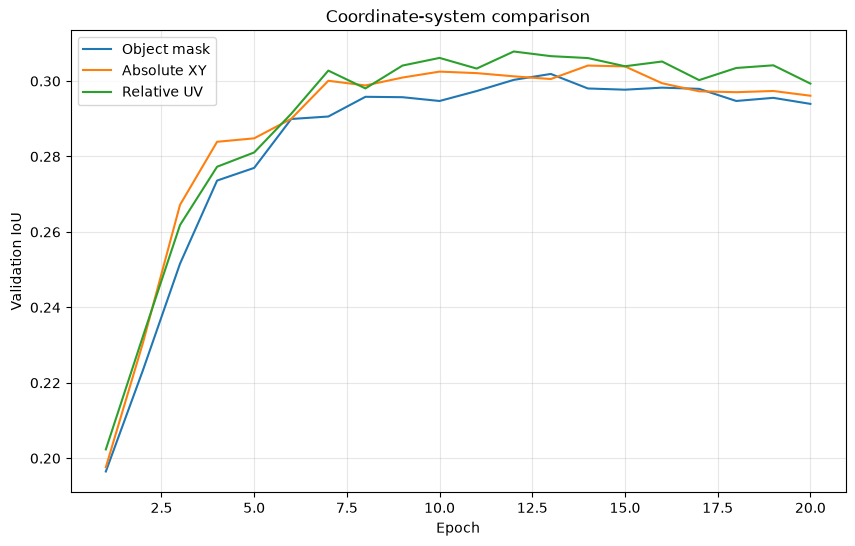

In [46]:
object_df = pd.DataFrame(
    object_history
)

xy_df = pd.DataFrame(
    xy_history
)

uv_df = pd.DataFrame(
    uv_history
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    object_df["epoch"],
    object_df["val_iou"],
    label="Object mask",
)

plt.plot(
    xy_df["epoch"],
    xy_df["val_iou"],
    label="Absolute XY",
)

plt.plot(
    uv_df["epoch"],
    uv_df["val_iou"],
    label="Relative UV",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation IoU"
)

plt.title(
    "Coordinate-system comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [47]:
def best_validation_row(
    history,
):

    df = pd.DataFrame(
        history
    )

    return df.loc[
        df["val_iou"].idxmax()
    ]


best_object = best_validation_row(
    object_history
)

best_xy = best_validation_row(
    xy_history
)

best_uv = best_validation_row(
    uv_history
)

In [48]:
validation_results = pd.DataFrame(
    [
        {
            "mode": "Object Mask",
            "best_epoch": int(
                best_object["epoch"]
            ),
            "val_iou": (
                best_object["val_iou"]
            ),
            "val_dice": (
                best_object["val_dice"]
            ),
        },

        {
            "mode": "Absolute XY",
            "best_epoch": int(
                best_xy["epoch"]
            ),
            "val_iou": (
                best_xy["val_iou"]
            ),
            "val_dice": (
                best_xy["val_dice"]
            ),
        },

        {
            "mode": "Relative UV",
            "best_epoch": int(
                best_uv["epoch"]
            ),
            "val_iou": (
                best_uv["val_iou"]
            ),
            "val_dice": (
                best_uv["val_dice"]
            ),
        },
    ]
)

validation_results

,mode,best_epoch,val_iou,val_dice
0,Object Mask,13,0.301888,0.396554
1,Absolute XY,14,0.304110,0.397505
2,Relative UV,12,0.307839,0.403310


In [49]:
def load_best_geometry_model(
    mode,
):

    checkpoint_path = (
        OUTPUT_ROOT
        / mode
        / "best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = (
        GeometryPartSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_dim=TEXT_DIM,
        )
        .to(DEVICE)
    )

    load_trainable_state(
        model,
        checkpoint,
    )

    model.eval()

    return (
        model,
        checkpoint,
    )

In [50]:
best_object_model, _ = (
    load_best_geometry_model(
        "object_mask"
    )
)

best_xy_model, _ = (
    load_best_geometry_model(
        "absolute_xy"
    )
)

best_uv_model, _ = (
    load_best_geometry_model(
        "relative_uv"
    )
)

In [51]:
@torch.no_grad()
def evaluate_model(
    model,
    loader,
):

    return run_epoch(
        model,
        loader,
        text_encoder,
        optimizer=None,
        scaler=None,
        threshold=MASK_THRESHOLD,
    )

In [52]:
object_seen = evaluate_model(
    best_object_model,
    test_seen_loader,
)

object_unseen = evaluate_model(
    best_object_model,
    test_unseen_loader,
)

print(
    "Seen:",
    object_seen
)

print(
    "Unseen:",
    object_unseen
)

Seen: {'loss': 0.6446309570953563, 'iou': 0.3165193314511286, 'dice': 0.4172578183312474}
Unseen: {'loss': 0.7236987193024624, 'iou': 0.26134584030467656, 'dice': 0.3543454184282623}


In [53]:
xy_seen = evaluate_model(
    best_xy_model,
    test_seen_loader,
)

xy_unseen = evaluate_model(
    best_xy_model,
    test_unseen_loader,
)

print(
    "Seen:",
    xy_seen
)

print(
    "Unseen:",
    xy_unseen
)

Seen: {'loss': 0.640255741109766, 'iou': 0.31828406277200794, 'dice': 0.41677066792511014}
Unseen: {'loss': 0.7477836060944902, 'iou': 0.24676548348549485, 'dice': 0.33914302505580957}


In [54]:
uv_seen = evaluate_model(
    best_uv_model,
    test_seen_loader,
)

uv_unseen = evaluate_model(
    best_uv_model,
    test_unseen_loader,
)

print(
    "Seen:",
    uv_seen
)

print(
    "Unseen:",
    uv_unseen
)

Seen: {'loss': 0.6433796101456685, 'iou': 0.3160218266343123, 'dice': 0.414646074701862}
Unseen: {'loss': 0.7193765574866556, 'iou': 0.265247943196892, 'dice': 0.36137498646486}


In [55]:
geometry_results = pd.DataFrame(
    [
        {
            "model": "Object Mask",
            "seen_iou": object_seen["iou"],
            "seen_dice": object_seen["dice"],
            "unseen_iou": object_unseen["iou"],
            "unseen_dice": object_unseen["dice"],
        },

        {
            "model": "Absolute XY",
            "seen_iou": xy_seen["iou"],
            "seen_dice": xy_seen["dice"],
            "unseen_iou": xy_unseen["iou"],
            "unseen_dice": xy_unseen["dice"],
        },

        {
            "model": "Relative UV",
            "seen_iou": uv_seen["iou"],
            "seen_dice": uv_seen["dice"],
            "unseen_iou": uv_unseen["iou"],
            "unseen_dice": uv_unseen["dice"],
        },
    ]
)

geometry_results

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,Object Mask,0.316519,0.417258,0.261346,0.354345
1,Absolute XY,0.318284,0.416771,0.246765,0.339143
2,Relative UV,0.316022,0.414646,0.265248,0.361375


In [56]:
uv_vs_mask_seen = (
    uv_seen["iou"]
    - object_seen["iou"]
)

uv_vs_mask_unseen = (
    uv_unseen["iou"]
    - object_unseen["iou"]
)

xy_vs_mask_seen = (
    xy_seen["iou"]
    - object_seen["iou"]
)

xy_vs_mask_unseen = (
    xy_unseen["iou"]
    - object_unseen["iou"]
)

uv_vs_xy_seen = (
    uv_seen["iou"]
    - xy_seen["iou"]
)

uv_vs_xy_unseen = (
    uv_unseen["iou"]
    - xy_unseen["iou"]
)

print(
    "Relative UV vs Object Mask"
)

print(
    f"Seen:   {uv_vs_mask_seen:+.4f}"
)

print(
    f"Unseen: {uv_vs_mask_unseen:+.4f}"
)

print()

print(
    "Absolute XY vs Object Mask"
)

print(
    f"Seen:   {xy_vs_mask_seen:+.4f}"
)

print(
    f"Unseen: {xy_vs_mask_unseen:+.4f}"
)

print()

print(
    "Relative UV vs Absolute XY"
)

print(
    f"Seen:   {uv_vs_xy_seen:+.4f}"
)

print(
    f"Unseen: {uv_vs_xy_unseen:+.4f}"
)

Relative UV vs Object Mask
Seen:   -0.0005
Unseen: +0.0039

Absolute XY vs Object Mask
Seen:   +0.0018
Unseen: -0.0146

Relative UV vs Absolute XY
Seen:   -0.0023
Unseen: +0.0185


# How to Interpret the Results

## Case 1

Object Mask < Absolute XY < Relative UV

Interpretation:

Explicit coordinates provide information beyond DINOv2, and expressing
coordinates relative to the parent object provides additional benefit over
ordinary image position.

This strongly supports the object-relative geometry hypothesis.

---

## Case 2

Object Mask < Absolute XY ≈ Relative UV

Interpretation:

Explicit position helps, but most of the benefit comes from providing
coordinates in general rather than from the object-relative reference frame.

---

## Case 3

Object Mask ≈ Absolute XY ≈ Relative UV

Interpretation:

DINOv2 likely already encodes sufficient spatial/structural information,
making explicit coordinates largely redundant.

This is consistent with the concern raised in the project feedback.

---

## Case 4

Relative UV < Object Mask

Interpretation:

The object-relative prior may introduce a harmful spatial bias.

This could happen when object parts do not have consistent positions or when
objects appear in unusual poses/orientations.

The rotation robustness experiment will be especially important in this case.

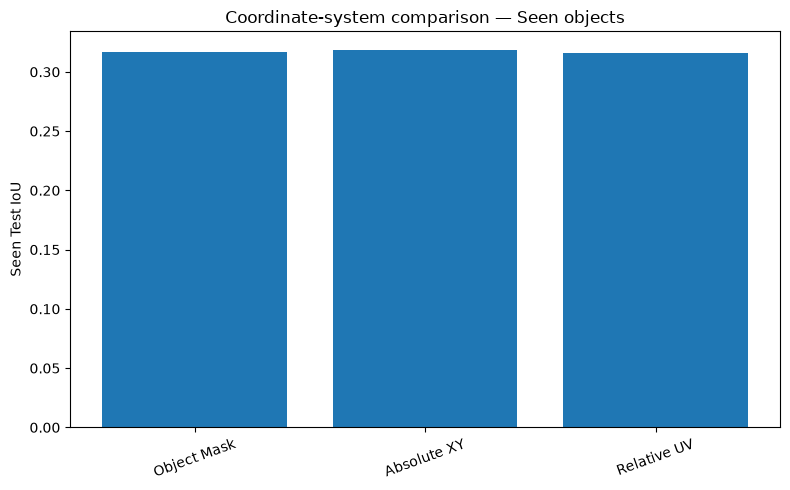

In [57]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    geometry_results["model"],
    geometry_results["seen_iou"],
)

plt.ylabel(
    "Seen Test IoU"
)

plt.title(
    "Coordinate-system comparison — Seen objects"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

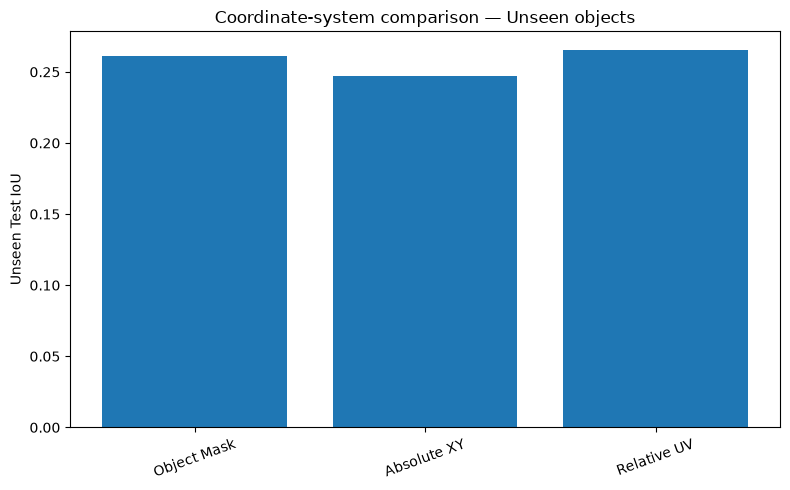

In [58]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    geometry_results["model"],
    geometry_results["unseen_iou"],
)

plt.ylabel(
    "Unseen Test IoU"
)

plt.title(
    "Coordinate-system comparison — Unseen objects"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [59]:
@torch.no_grad()
def predict_one(
    model,
    sample,
):

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    object_mask = (
        sample["object_mask"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    absolute_x = (
        sample["absolute_x"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    absolute_y = (
        sample["absolute_y"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_u = (
        sample["relative_u"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_v = (
        sample["relative_v"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    text_embedding = text_encoder(
        [
            sample["query"]
        ]
    )

    logits = model(
        image,
        text_embedding,
        object_mask,
        absolute_x,
        absolute_y,
        relative_u,
        relative_v,
    )

    probability = (
        torch.sigmoid(logits)
        [0, 0]
        .cpu()
    )

    prediction = (
        probability
        >= MASK_THRESHOLD
    )

    return (
        probability,
        prediction,
    )

In [60]:
idx = random.randrange(
    len(test_unseen_dataset)
)

sample = (
    test_unseen_dataset[idx]
)

_, object_pred = predict_one(
    best_object_model,
    sample,
)

_, xy_pred = predict_one(
    best_xy_model,
    sample,
)

_, uv_pred = predict_one(
    best_uv_model,
    sample,
)

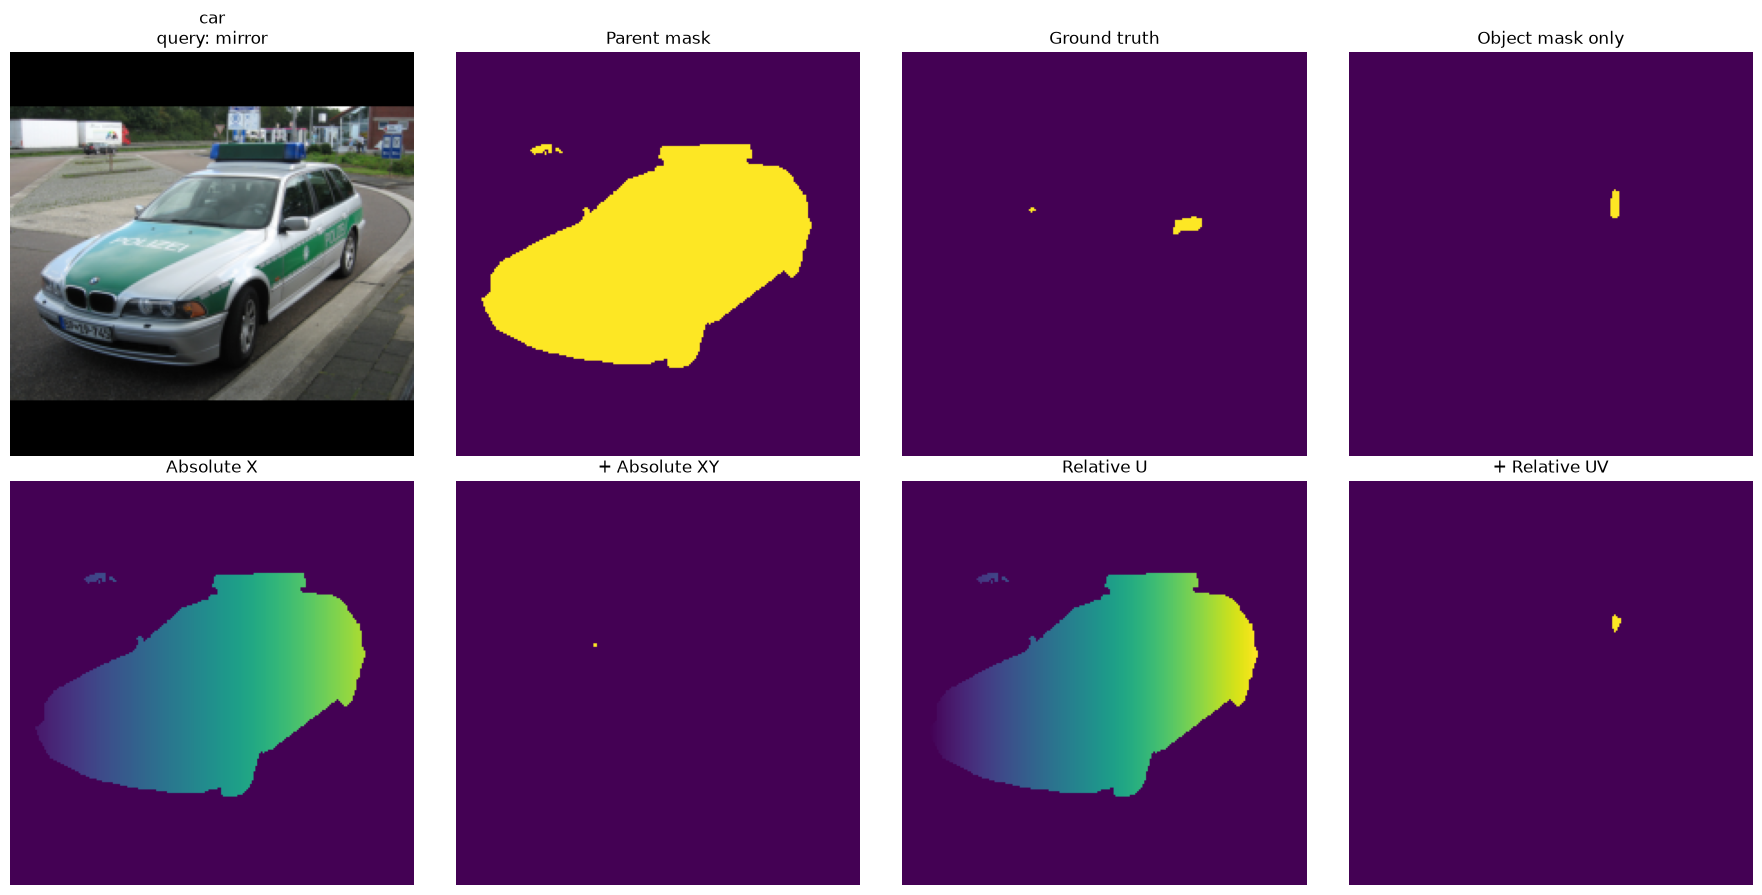

In [61]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
)

axes[0, 0].imshow(
    sample["display_image"]
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    f"{sample['object_name']}\n"
    f"query: {sample['query']}"
)

axes[0, 1].imshow(
    sample["object_mask"]
    .squeeze()
)

axes[0, 1].set_title(
    "Parent mask"
)

axes[0, 2].imshow(
    sample["part_mask"]
    .squeeze()
)

axes[0, 2].set_title(
    "Ground truth"
)

axes[0, 3].imshow(
    object_pred
)

axes[0, 3].set_title(
    "Object mask only"
)

axes[1, 0].imshow(
    sample["absolute_x"]
    .squeeze(),
    vmin=0,
    vmax=1,
)

axes[1, 0].set_title(
    "Absolute X"
)

axes[1, 1].imshow(
    xy_pred
)

axes[1, 1].set_title(
    "+ Absolute XY"
)

axes[1, 2].imshow(
    sample["relative_u"]
    .squeeze(),
    vmin=0,
    vmax=1,
)

axes[1, 2].set_title(
    "Relative U"
)

axes[1, 3].imshow(
    uv_pred
)

axes[1, 3].set_title(
    "+ Relative UV"
)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()

plt.show()

In [62]:
results_path = (
    OUTPUT_ROOT
    / "geometry_results.csv"
)

geometry_results.to_csv(
    results_path,
    index=False,
)

print(
    "Saved:",
    results_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/geometry/geometry_results.csv


In [63]:
summary = {
    "object_mask": {
        "seen": object_seen,
        "unseen": object_unseen,
    },

    "absolute_xy": {
        "seen": xy_seen,
        "unseen": xy_unseen,
    },

    "relative_uv": {
        "seen": uv_seen,
        "unseen": uv_unseen,
    },

    "iou_differences": {
        "relative_uv_vs_object_mask_seen": (
            uv_vs_mask_seen
        ),

        "relative_uv_vs_object_mask_unseen": (
            uv_vs_mask_unseen
        ),

        "absolute_xy_vs_object_mask_seen": (
            xy_vs_mask_seen
        ),

        "absolute_xy_vs_object_mask_unseen": (
            xy_vs_mask_unseen
        ),

        "relative_uv_vs_absolute_xy_seen": (
            uv_vs_xy_seen
        ),

        "relative_uv_vs_absolute_xy_unseen": (
            uv_vs_xy_unseen
        ),
    },
}

with open(
    OUTPUT_ROOT
    / "geometry_summary.json",
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

In [64]:
baseline_path = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "baseline_results.csv"
)

if baseline_path.exists():

    old_baseline = (
        pd.read_csv(
            baseline_path
        )
    )

    print(
        "Notebook 03 results:"
    )

    display(
        old_baseline
    )

else:

    print(
        "Notebook 03 baseline file not found."
    )

Notebook 03 results:


,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,DINO + CLIP,0.298047,0.394139,0.140982,0.201020
1,DINO + CLIP + Object Mask,0.311884,0.410370,0.214519,0.297118


# Notebook 04 Summary

This notebook performed the project's first controlled study of explicit
spatial encoding.

Three models were trained with identical architecture and parameter count.

## Object Mask

DINOv2 + CLIP + parent-object mask

No explicit coordinate information.

---

## Absolute XY

DINOv2 + CLIP + parent-object mask + absolute image coordinates.

This tests whether simply providing explicit spatial position helps beyond
the strong DINOv2 representation.

---

## Relative UV

DINOv2 + CLIP + parent-object mask + coordinates normalized relative to
the selected parent object.

This tests whether the object-relative reference frame provides additional
value beyond ordinary image coordinates.

---

## Central Comparisons

Relative UV vs Object Mask

→ Does object-relative geometry add information beyond DINOv2 and parent
object conditioning?

Absolute XY vs Object Mask

→ Does explicit position in general help?

Relative UV vs Absolute XY

→ Is the object-relative coordinate system itself useful?

---

## Important Limitation

U/V coordinates are axis aligned.

For example, a head may normally occur near low V values for an upright
animal or person.

After rotating the object, the same head may occur at a high V value.

Therefore relative U/V may encode a canonical-orientation bias.

This motivates the next robustness experiment.